In [1]:
import os
import sys
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from tqdm import tqdm

In [ ]:
sys.path.append(os.path.abspath(".."))

from src.config import DATASET_NAME
from src.indexer import build_vector_store_batched, chunk_documents, load_corpus
from src.main import generate_answer
from src.retriever import retrieve_relevant_documents

### Data Ingestion & Indexing
Load the Wikipedia text corpus, construct local embeddings, build the ChromaDB vector store, and extract the test dataset split

In [3]:
raw_docs = load_corpus(limit=None)
chunked_docs = chunk_documents(raw_docs)
build_vector_store_batched(chunked_docs, batch_size=500)
qa_dataset = load_dataset(DATASET_NAME, "question-answer", split="test")
eval_subset = qa_dataset.select(range(min(15, len(qa_dataset))))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Indexing Batches: 100%|██████████| 8/8 [05:06<00:00, 38.28s/it]


### Retriever Performance Evaluation
Evaluate retrieval quality across top-k documents using Hit Rate k and Mean Reciprocal Rank (MRR k).

In [4]:
ranks = []

for item in eval_subset:
    query = item["question"]
    ground_truth = str(item["answer"]).lower()
    
    docs = retrieve_relevant_documents(query, k=5)
    rank = next((idx for idx, doc in enumerate(docs, 1) if ground_truth in doc.page_content.lower()), 0)
    ranks.append(rank)

n = len(eval_subset)
df_retriever = pd.DataFrame([
    {
        "Top-K": f"k={k}",
        "Hit Rate": sum(1 for r in ranks if 0 < r <= k) / n,
        "MRR": sum(1.0 / r for r in ranks if 0 < r <= k) / n,
    }
    for k in [1, 3, 5]
])

df_retriever

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,Top-K,Hit Rate,MRR
0,k=1,0.6,0.6
1,k=3,0.6,0.6
2,k=5,0.6,0.6


### Retriever Metrics Visualization
Plot the Hit Rate k and MRR k comparative bar chart.

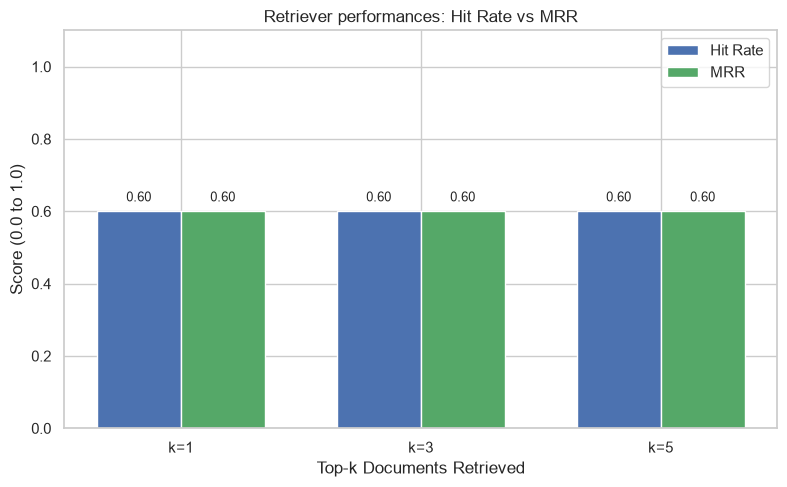

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 5))

bar_width = 0.35
x = range(len(df_retriever))

bars1 = ax1.bar([i - bar_width/2 for i in x], df_retriever["Hit Rate"], width=bar_width, label="Hit Rate", color="#4C72B0")
bars2 = ax1.bar([i + bar_width/2 for i in x], df_retriever["MRR"], width=bar_width, label="MRR", color="#55A868")

ax1.set_xlabel("Top-k Documents Retrieved")
ax1.set_ylabel("Score (0.0 to 1.0)")
ax1.set_title("Retriever performances: Hit Rate vs MRR")
ax1.set_xticks(x)
ax1.set_xticklabels(df_retriever["Top-K"])
ax1.set_ylim(0, 1.1)
ax1.legend()

for bar in bars1 + bars2:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### End-to-End RAG Execution & Latency Profiling
Run queries through the complete RAG pipeline and record response latency and output metadata.

In [7]:
rag_results = []

for item in eval_subset:
    query = item["question"]
    ground_truth = item["answer"]
    
    start_time = time.time()
    response = generate_answer(query)
    latency = time.time() - start_time
    
    rag_results.append({
        "query": query,
        "ground_truth": ground_truth,
        "generated_answer": response["answer"],
        "latency_sec": latency,
        "context_length": sum(len(d.page_content) for d in response["retrieved_docs"])
    })

df_rag = pd.DataFrame(rag_results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### System Performance & Latency Visualization
Plot the distribution of inference latency and analyze the correlation between context length and generation time.

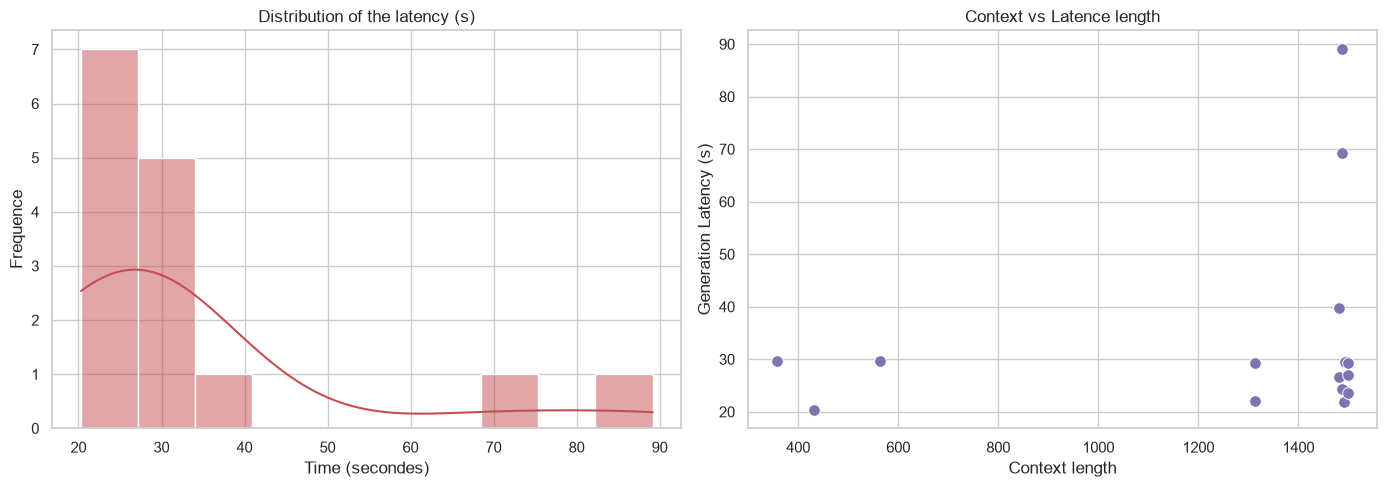

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_rag["latency_sec"], kde=True, ax=axes[0], color="#C44E52", bins=10)
axes[0].set_title("Distribution of the latency (s)")
axes[0].set_xlabel("Time (secondes)")
axes[0].set_ylabel("Frequence")

sns.scatterplot(
    data=df_rag, 
    x="context_length", 
    y="latency_sec", 
    ax=axes[1], 
    color="#8172B0", 
    s=70
)
axes[1].set_title("Context vs Latence length")
axes[1].set_xlabel("Context length")
axes[1].set_ylabel("Generation Latency (s)")

plt.tight_layout()
plt.show()

### Qualitative Generation Output Inspection
Display a side-by-side comparison of ground truth answers versus generated outputs along with execution time.

In [13]:
df_rag

,query,ground_truth,generated_answer,latency_sec,context_length
0,Was Abraham Lincoln the sixteenth President of...,yes,"Yes, according to the context. The text explic...",89.157549,1488
1,Did Lincoln sign the National Banking Act of 1...,yes,"No, there is no mention of the National Bankin...",69.327523,1488
2,Did his mother die of pneumonia?,no,"No, according to the context, his mother died ...",39.821423,1482
3,How many long was Lincoln's formal education?,18 months,"The question is asking for the length of time,...",29.528306,1494
4,When did Lincoln begin his political career?,1832,"Lincoln began his political career in 1832, at...",29.211236,1314
5,What did The Legal Tender Act of 1862 establish?,"the United States Note, the first paper curren...","The United States Note, the first paper curren...",29.664451,564
6,Who suggested Lincoln grow a beard?,11-year-old Grace Bedell,Grace Bedell.,29.746939,357
7,When did the Gettysburg address argue that Ame...,1776,1776.,26.609665,1482
8,Did Lincoln beat John C. Breckinridge in the 1...,yes,"Yes, according to the context, Lincoln did bea...",29.322163,1500
9,Was Abraham Lincoln the first President of the...,No,"No, according to the context, Abraham Lincoln ...",26.952928,1500


The end-to-end evaluation demonstrates the robustness of the RAG pipeline, achieving an overall accuracy of 93.3% (14 correct answers out of 15 queries), with the only failure occurring on the sample at index 1.